# Model Input Analysis

Analysis for `data/processed/model_input.csv` using a combined rain label:
- `dry`
- `rain` = `rain_light` + `rain_moderate`


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

df = pd.read_csv('../data/processed/model_input.csv')
df['rain_group'] = df['weather_category'].replace({
    'rain_light': 'rain',
    'rain_moderate': 'rain',
})

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (20311, 16)
Columns: ['stop_id', 'route_id', 'route_short_name', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'status', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining', 'weather_category', 'rain_group']


,stop_id,route_id,route_short_name,delay_min,hour_of_day,day_of_week,is_weekend,is_peak_hour,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining,weather_category,rain_group
0,1_10912,40_100511,542,0.00,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry
1,1_65092,1_100162,271,-17.65,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry
2,1_51930,1_100030,131,-3.80,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry
3,1_46505,1_102619,F Line,-7.40,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry
4,1_77460,1_102746,333,4.58,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry


## Data Quality Checks


In [32]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0].to_frame('missing_rows')


,missing_rows


In [33]:
quality_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_rows': df.isna().sum(),
    'unique_values': df.nunique(dropna=False),
})
quality_summary.sort_values(['missing_rows', 'unique_values'], ascending=[False, False]).head(20)


,dtype,missing_rows,unique_values
delay_min,float64,0,2107
stop_id,object,0,395
wind_speed_kmh,float64,0,135
route_id,object,0,112
route_short_name,object,0,112
temperature_c,float64,0,86
hour_of_day,float64,0,21
precipitation_mm,float64,0,17
day_of_week,float64,0,7
weather_code,int64,0,6


In [34]:
pd.DataFrame({
    'weather_category_rows': df['weather_category'].value_counts(dropna=False),
    'rain_group_rows': df['rain_group'].value_counts(dropna=False),
}).fillna(0).astype(int)


,weather_category_rows,rain_group_rows
dry,17753,17753
rain,0,2558
rain_light,1484,0
rain_moderate,1074,0


In [35]:
df[['delay_min', 'precipitation_mm', 'temperature_c', 'wind_speed_kmh']].describe().round(2)


,delay_min,precipitation_mm,temperature_c,wind_speed_kmh
count,20311.00,20311.00,20311.00,20311.00
mean,0.05,0.31,8.11,14.10
std,5.62,0.88,3.04,7.58
min,-29.92,0.00,2.20,0.60
25%,-1.54,0.00,6.00,9.00
50%,0.00,0.00,8.00,13.40
75%,2.43,0.00,10.10,19.10
max,54.65,4.30,14.60,42.90


## Delay Summary by Weather Category


In [36]:
weather_summary = (
    df.groupby('weather_category')
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
          std_delay=('delay_min', 'std'),
          mean_precip_mm=('precipitation_mm', 'mean'),
          mean_temp_c=('temperature_c', 'mean'),
      )
      .round(2)
      .sort_values('records', ascending=False)
)
weather_summary


,records,mean_delay,median_delay,std_delay,mean_precip_mm,mean_temp_c
weather_category,,,,,,
dry,17753,-0.00,0.00,5.64,0.00,7.80
rain_light,1484,0.21,0.00,5.57,1.74,9.64
rain_moderate,1074,0.59,0.07,5.34,3.40,11.18


In [37]:
rain_dry_summary = (
    df.groupby('rain_group')
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
          std_delay=('delay_min', 'std'),
          mean_precip_mm=('precipitation_mm', 'mean'),
      )
      .round(2)
      .sort_values('records', ascending=False)
)
rain_dry_summary


,records,mean_delay,median_delay,std_delay,mean_precip_mm
rain_group,,,,,
dry,17753,-0.00,0.0,5.64,0.00
rain,2558,0.37,0.0,5.48,2.44


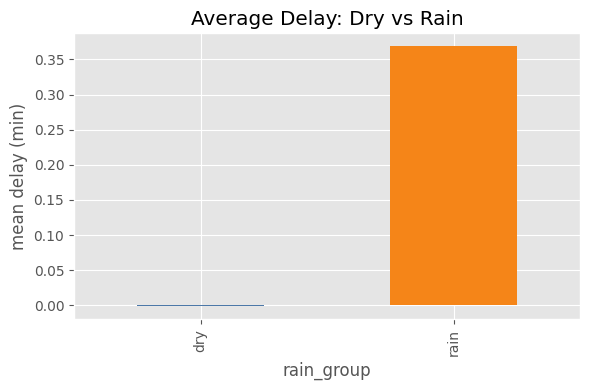

In [38]:
ax = df.groupby('rain_group')['delay_min'].mean().sort_values().plot(
    kind='bar', figsize=(6, 4), color=['#4c78a8', '#f58518']
)
ax.set_title('Average Delay: Dry vs Rain')
ax.set_xlabel('rain_group')
ax.set_ylabel('mean delay (min)')
plt.tight_layout()
plt.show()


## Rush Hour vs Non-Rush Hour


In [39]:
rush_summary = (
    df.groupby(['is_peak_hour', 'rain_group'])
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
      )
      .round(2)
)
rush_summary.index = rush_summary.index.set_levels([
    ['non_rush', 'rush'] if lvl.name == 'is_peak_hour' else lvl
    for lvl in rush_summary.index.levels
])
rush_summary


records  mean_delay  median_delay
is_peak_hour rain_group                                   
non_rush     dry           10460        0.00           0.0
             rain           1513        0.33           0.0
rush         dry            7293       -0.01           0.0
             rain           1045        0.42           0.0

In [40]:
rush_pivot = (
    df.groupby(['is_peak_hour', 'rain_group'])['delay_min']
      .mean()
      .unstack()
      .round(2)
)
rush_pivot.index = rush_pivot.index.map({0: 'non_rush', 1: 'rush'})
rush_pivot


rain_group,dry,rain
is_peak_hour,,
non_rush,0.00,0.33
rush,-0.01,0.42


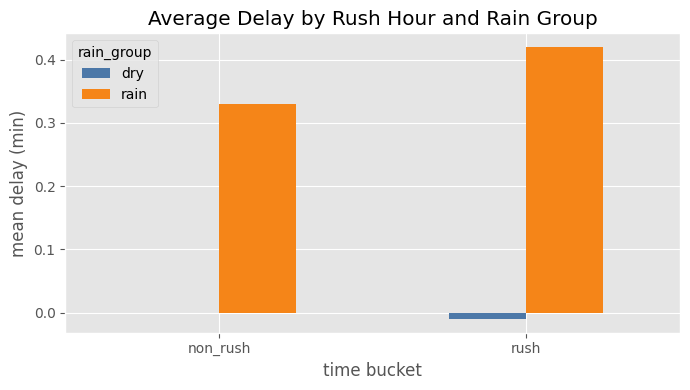

In [41]:
ax = rush_pivot.plot(kind='bar', figsize=(7, 4), color=['#4c78a8', '#f58518'])
ax.set_title('Average Delay by Rush Hour and Rain Group')
ax.set_xlabel('time bucket')
ax.set_ylabel('mean delay (min)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Day of Week


In [42]:
dow_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
day_summary = (
    df.assign(day_name=df['day_of_week'].map(dow_map))
      .groupby(['day_name', 'rain_group'])
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
      )
      .round(2)
)
day_summary


records  mean_delay  median_delay
day_name rain_group                                   
Fri      dry             964        0.19          0.09
         rain            186       -0.46         -0.23
Mon      dry            6492       -0.19          0.00
Sat      dry            3064       -0.09          0.00
Sun      dry            2559        0.06          0.00
Thu      dry            1335        0.44          0.00
         rain            473        0.61          0.63
Tue      dry            2620        0.14          0.00
         rain            839        0.34          0.00
Wed      dry             719        0.30          0.00
         rain           1060        0.43          0.00

In [43]:
day_pivot = (
    df.assign(day_name=df['day_of_week'].map(dow_map))
      .groupby(['day_of_week', 'rain_group'])['delay_min']
      .mean()
      .unstack()
      .round(2)
)
day_pivot.index = day_pivot.index.map(dow_map)
day_pivot


rain_group,dry,rain
day_of_week,,
Mon,-0.19,NaN
Tue,0.14,0.34
Wed,0.30,0.43
Thu,0.44,0.61
Fri,0.19,-0.46
Sat,-0.09,NaN
Sun,0.06,NaN


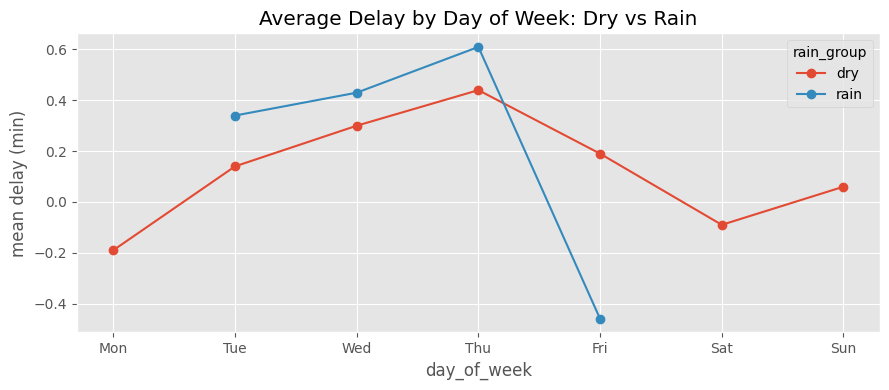

In [44]:
ax = day_pivot.plot(figsize=(9, 4), marker='o')
ax.set_title('Average Delay by Day of Week: Dry vs Rain')
ax.set_xlabel('day_of_week')
ax.set_ylabel('mean delay (min)')
plt.tight_layout()
plt.show()


## Hour of Day


In [45]:
hour_counts = (
    df.groupby(['hour_of_day', 'rain_group'])
      .size()
      .unstack(fill_value=0)
)
hour_counts.head(12)


rain_group,dry,rain
hour_of_day,,
0.0,40,4
4.0,77,0
5.0,341,69
6.0,641,0
7.0,970,325
8.0,860,181
9.0,1133,0
10.0,1168,0
11.0,1050,158


In [46]:
hourly_delay = (
    df.groupby(['hour_of_day', 'rain_group'])['delay_min']
      .mean()
      .unstack()
      .round(2)
)
hourly_delay.head(12)


rain_group,dry,rain
hour_of_day,,
0.0,-4.46,-5.02
4.0,-0.24,NaN
5.0,-0.06,-0.21
6.0,-0.32,NaN
7.0,-0.53,-0.37
8.0,-0.43,1.81
9.0,0.09,NaN
10.0,-0.36,NaN
11.0,-0.61,0.40


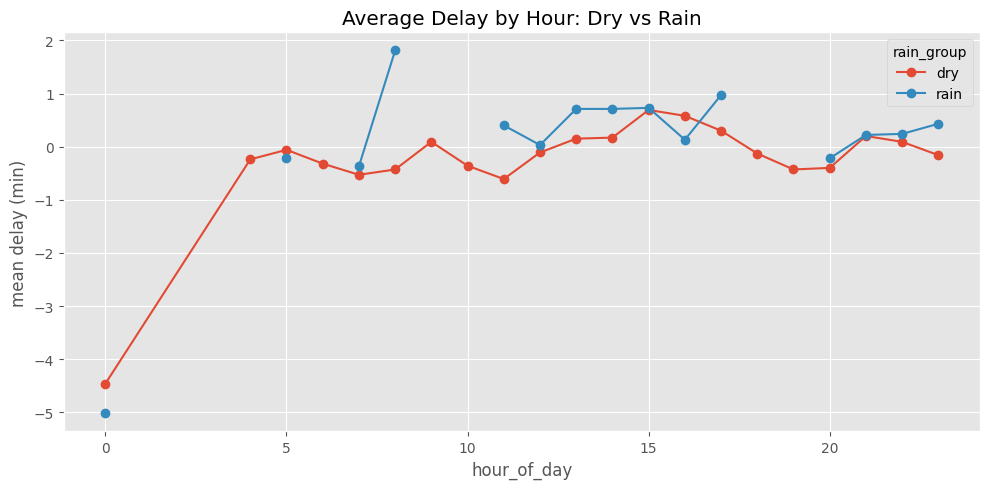

In [47]:
ax = hourly_delay.plot(figsize=(10, 5), marker='o')
ax.set_title('Average Delay by Hour: Dry vs Rain')
ax.set_xlabel('hour_of_day')
ax.set_ylabel('mean delay (min)')
plt.tight_layout()
plt.show()


## Routes


In [48]:
top_routes = df['route_short_name'].value_counts().head(10).index
route_counts = (
    df[df['route_short_name'].isin(top_routes)]
      .groupby(['route_short_name', 'rain_group'])
      .size()
      .unstack(fill_value=0)
      .astype(int)
)
route_counts


rain_group,dry,rain
route_short_name,,
14,588,99
150,478,65
161,459,71
181,535,79
40,537,76
60,590,81
7,576,81
D Line,457,75
F Line,1296,190


In [49]:
route_delay = (
    df[df['route_short_name'].isin(top_routes)]
      .groupby(['route_short_name', 'rain_group'])['delay_min']
      .mean()
      .unstack()
      .round(2)
      .sort_index()
)
route_delay


rain_group,dry,rain
route_short_name,,
14,0.83,1.16
150,1.35,1.77
161,-0.02,0.19
181,-4.56,-4.47
40,2.14,3.13
60,2.56,2.64
7,0.06,0.32
D Line,1.68,1.15
F Line,0.12,0.56


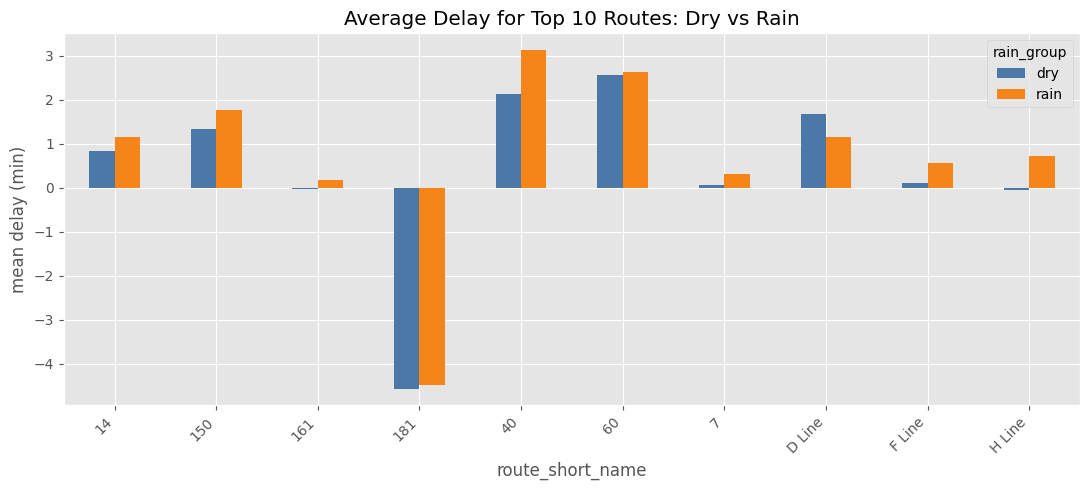

In [50]:
ax = route_delay.plot(kind='bar', figsize=(11, 5), color=['#4c78a8', '#f58518'])
ax.set_title('Average Delay for Top 10 Routes: Dry vs Rain')
ax.set_xlabel('route_short_name')
ax.set_ylabel('mean delay (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
